#  Coursework Report
## Binary Pneumonia Classification from Chest X-ray Images

**Course:** Deep Learning  
**Model family:** Convolutional Neural Network  
**Dataset used in this notebook:** 5,856 chest X-ray images organized as `NORMAL` and `PNEUMONIA`  
**Kaggle source supplied by the group:** [Dataset NIH ChestX-ray14](https://www.kaggle.com/datasets/nguynhongmaivy/dataset-nih-chestx-ray14)

### Important scope audit

The executed notebook and its folder structure implement **binary image classification**, not patient-age regression. The observed dataset contains class folders `NORMAL` and `PNEUMONIA`, with no patient-age target in the executed pipeline. Therefore, the numerical results in this report must be described as pneumonia-classification results. They cannot be reported as evidence for age regression.

If the lecturer requires the original brief `CNN + Global Average Pooling + Linear(1) → Patient Age`, the group must use NIH metadata containing `Patient Age` and rerun a regression pipeline with MAE/MSE/RMSE. This notebook intentionally avoids inventing age-regression results.


## 1. Problem definition

The empirical task solved here is to predict whether a chest X-ray belongs to the `NORMAL` or `PNEUMONIA` class.

- Input: chest X-ray image.
- Output: one of two class labels.
- Loss: cross-entropy.
- Primary reported metric: test accuracy.
- Additional metrics: precision, recall and F1-score by class.

This task can support educational analysis of CNNs, augmentation and model evaluation. It is not a clinical diagnostic system.


In [1]:
# Import libraries

import os
import random
import copy
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

from IPython.display import display

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

PyTorch version: 2.13.0+cu126
CUDA available: True


In [2]:
# Reproducibility configuration

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

seed_everything(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", DEVICE)
device = DEVICE  # alias used by the training/evaluation cells below

# Main hyperparameters

IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 1e-4
NUM_WORKERS = 0

print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Using device: cuda
Image size: 224
Batch size: 32
Epochs: 10
Learning rate: 0.0001


## 2. Dataset configuration and exploratory analysis

The dataset is stored in `train`, `val` and `test` folders. Each split contains `NORMAL` and `PNEUMONIA` subfolders. The executed environment used `CourseWork/chest_xray` as the data root.

The validation set contains only 16 images, which is a major limitation. Validation accuracy therefore changes by 6.25 percentage points when only one prediction changes. Model selection based on this set has high uncertainty.


In [3]:
from pathlib import Path

# Notebook hiện tại nằm trong thư mục CourseWork
CURRENT_DIR = Path.cwd()

print("Thư mục hiện tại:")
print(CURRENT_DIR)

# Dataset của bạn nằm trong:
# CourseWork/chest_xray/
DATA_ROOT = CURRENT_DIR / "chest_xray"

print("\nĐường dẫn dataset:")
print(DATA_ROOT)

print("\nDataset tồn tại:", DATA_ROOT.exists())

if not DATA_ROOT.exists():
    raise FileNotFoundError(
        f"Không tìm thấy dataset tại: {DATA_ROOT}\n"
        "Hãy kiểm tra lại vị trí thư mục chest_xray."
    )

print("\nCác thư mục bên trong dataset:")
for item in DATA_ROOT.iterdir():
    print(item.name)
    

Thư mục hiện tại:
d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\CourseWork

Đường dẫn dataset:
d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\CourseWork\chest_xray

Dataset tồn tại: True

Các thư mục bên trong dataset:
chest_xray
test
train
val
__MACOSX


In [4]:
for split in ["train", "test", "val"]:
    split_path = DATA_ROOT / split

    print(f"\n{split.upper()}")

    if split_path.exists():
        for class_dir in split_path.iterdir():
            if class_dir.is_dir():
                image_count = len(list(class_dir.glob("*")))
                print(
                    f"{class_dir.name}: "
                    f"{image_count} ảnh"
                )
    else:
        print("Không tìm thấy thư mục này.")


TRAIN
NORMAL: 1341 ảnh
PNEUMONIA: 3875 ảnh

TEST
NORMAL: 234 ảnh
PNEUMONIA: 390 ảnh

VAL
NORMAL: 8 ảnh
PNEUMONIA: 8 ảnh


In [5]:
from pathlib import Path
import pandas as pd

# Các định dạng ảnh được hỗ trợ
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

# Lưu thông tin ảnh
image_records = []

for split in ["train", "val", "test"]:
    split_path = DATA_ROOT / split

    if not split_path.exists():
        print(f"Không tìm thấy thư mục: {split_path}")
        continue

    for class_dir in sorted(split_path.iterdir()):
        if not class_dir.is_dir():
            continue

        label = class_dir.name.upper()

        for image_path in class_dir.iterdir():
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                image_records.append({
                    "image_path": str(image_path),
                    "label": label,
                    "split": split
                })

df = pd.DataFrame(image_records)

print("Tổng số ảnh:", len(df))
display(df.head())

Tổng số ảnh: 5856


,image_path,label,split
0,d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-...,NORMAL,train
1,d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-...,NORMAL,train
2,d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-...,NORMAL,train
3,d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-...,NORMAL,train
4,d:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-...,NORMAL,train


In [6]:
print("Số lượng ảnh theo tập dữ liệu:")
display(df["split"].value_counts())

print("\nSố lượng ảnh theo nhãn:")
display(df["label"].value_counts())

print("\nBảng phân bố ảnh:")
distribution_table = pd.crosstab(
    df["split"],
    df["label"]
)

display(distribution_table)

Số lượng ảnh theo tập dữ liệu:


split
train    5216
test      624
val        16
Name: count, dtype: int64


Số lượng ảnh theo nhãn:


label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64


Bảng phân bố ảnh:


label,NORMAL,PNEUMONIA
split,,
test,234,390
train,1341,3875
val,8,8


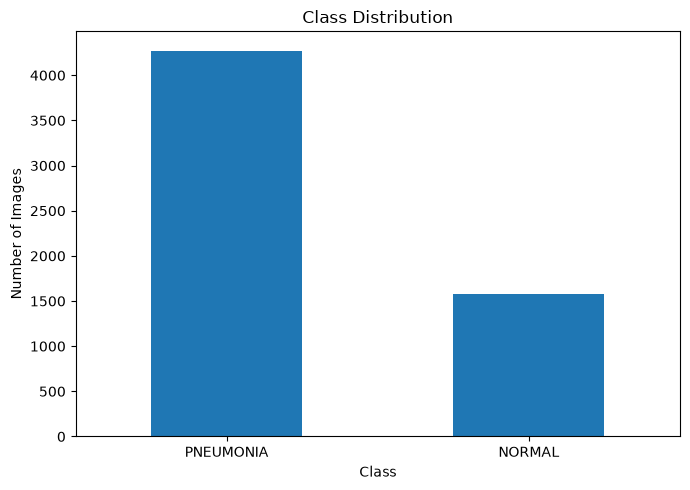

In [7]:
import matplotlib.pyplot as plt

label_counts = df["label"].value_counts()

plt.figure(figsize=(7, 5))
label_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

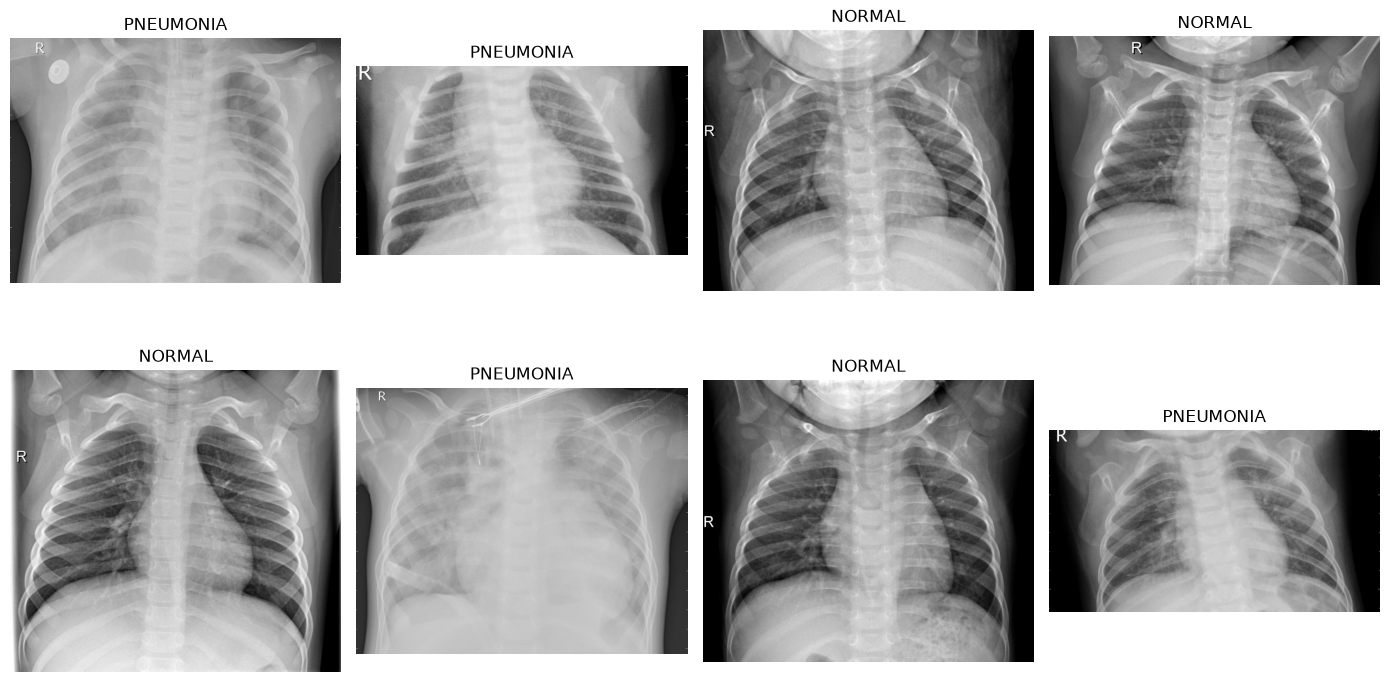

In [8]:
import matplotlib.pyplot as plt
from PIL import Image

sample_df = df.sample(
    n=min(8, len(df)),
    random_state=42
).reset_index(drop=True)

plt.figure(figsize=(14, 8))

for i, row in sample_df.iterrows():
    image = Image.open(row["image_path"]).convert("L")

    plt.subplot(2, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(row["label"])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
image_sizes = []

for image_path in df["image_path"].sample(
    n=min(500, len(df)),
    random_state=42
):
    try:
        with Image.open(image_path) as image:
            image_sizes.append(image.size)
    except Exception:
        pass

size_df = pd.DataFrame(
    image_sizes,
    columns=["width", "height"]
)

display(size_df.describe())

,width,height
count,500.000000,500.000000
mean,1327.444000,976.636000
std,352.692061,380.470049
min,437.000000,132.000000
25%,1064.000000,694.000000
50%,1296.000000,904.000000
75%,1566.500000,1201.500000
max,2694.000000,2625.000000


### Dataset findings

| Split | Normal | Pneumonia | Total |
|---|---:|---:|---:|
| Train | 1,341 | 3,875 | 5,216 |
| Validation | 8 | 8 | 16 |
| Test | 234 | 390 | 624 |
| **Total** | **1,583** | **4,273** | **5,856** |

The dataset is imbalanced toward pneumonia. Accuracy alone is therefore insufficient; recall and F1-score must be examined for both classes. Image dimensions vary substantially, so all images are resized to 224×224 before batching.


## 3. Preprocessing and data augmentation — Member 05

Training-time augmentation uses random horizontal flipping and rotation. Validation and test images receive deterministic resizing and normalization only.

The purpose of augmentation is to reduce overfitting by exposing the model to small appearance variations. Rotation should remain mild because large rotations can create anatomically unrealistic X-rays. The current 10° limit is acceptable for an educational experiment, though a controlled no-augmentation baseline is required to quantify its effect.


In [10]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [11]:
train_dir = DATA_ROOT / "train"
val_dir = DATA_ROOT / "val"
test_dir = DATA_ROOT / "test"

train_dataset = datasets.ImageFolder(
    root=train_dir,
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=val_dir,
    transform=val_test_transform
)

test_dataset = datasets.ImageFolder(
    root=test_dir,
    transform=val_test_transform
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("\nSố ảnh train:", len(train_dataset))
print("Số ảnh validation:", len(val_dataset))
print("Số ảnh test:", len(test_dataset))

Classes: ['NORMAL', 'PNEUMONIA']
Class mapping: {'NORMAL': 0, 'PNEUMONIA': 1}

Số ảnh train: 5216
Số ảnh validation: 16
Số ảnh test: 624


In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Đã tạo DataLoader thành công.")

Đã tạo DataLoader thành công.


In [13]:
images, labels = next(iter(train_loader))

print("Kích thước batch ảnh:", images.shape)
print("Kích thước batch nhãn:", labels.shape)
print("Nhãn trong batch:", labels[:10])

Kích thước batch ảnh: torch.Size([32, 3, 224, 224])
Kích thước batch nhãn: torch.Size([32])
Nhãn trong batch: tensor([1, 1, 0, 1, 1, 1, 1, 1, 0, 1])


## 4. CNN architecture

The model uses three convolution/max-pooling blocks followed by a fully connected classifier. The executed model contains 25,784,130 trainable parameters, most of which come from flattening the 128×28×28 feature map.

This architecture is valid for the classification experiment, but it does **not** meet an age-regression rubric that explicitly requires Global Average Pooling and `Linear(1)`. For classification, a GAP-based head would also be a useful improvement because it would reduce parameters and overfitting risk.


In [14]:
class ChestXRayCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(
                in_channels=3,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 2
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),

            # Block 3
            nn.Conv2d(
                in_channels=64,
                out_channels=128,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(
                128 * 28 * 28,
                256
            ),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            nn.Linear(256, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


model = ChestXRayCNN().to(device)

print(model)

ChestXRayCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)


In [15]:
total_params = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_params = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print("Tổng số tham số:", total_params)
print("Số tham số có thể huấn luyện:", trainable_params)

Tổng số tham số: 25784130
Số tham số có thể huấn luyện: 25784130


## 5. Training protocol

- Optimizer: Adam.
- Learning rate: 0.001 in the executed training cell.
- Epochs: 10.
- Objective: cross-entropy loss.
- Checkpoint selection: smallest validation loss.
- Reproducibility seed: 42.

The learning rate differs from the earlier configuration cell (`1e-4`). The executed training cell uses `1e-3`; this is the value that should be reported for the presented results.


In [16]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

EPOCHS = 10

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [18]:
def evaluate_model(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predictions.cpu().numpy())

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return (
        epoch_loss,
        epoch_accuracy,
        all_labels,
        all_predictions
    )

In [19]:
from copy import deepcopy

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss = float("inf")
best_model_state = None

for epoch in range(EPOCHS):
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy, _, _ = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_accuracy)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_accuracy)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = deepcopy(model.state_dict())

    print(
        f"Epoch [{epoch + 1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )

Epoch [1/10] | Train Loss: 0.2452 | Train Acc: 0.9009 | Val Loss: 0.6007 | Val Acc: 0.6875
Epoch [2/10] | Train Loss: 0.1328 | Train Acc: 0.9488 | Val Loss: 0.7076 | Val Acc: 0.6250
Epoch [3/10] | Train Loss: 0.1176 | Train Acc: 0.9571 | Val Loss: 1.2416 | Val Acc: 0.5625
Epoch [4/10] | Train Loss: 0.0943 | Train Acc: 0.9638 | Val Loss: 0.7257 | Val Acc: 0.6250
Epoch [5/10] | Train Loss: 0.0870 | Train Acc: 0.9661 | Val Loss: 0.6174 | Val Acc: 0.7500
Epoch [6/10] | Train Loss: 0.0865 | Train Acc: 0.9680 | Val Loss: 1.1166 | Val Acc: 0.5625
Epoch [7/10] | Train Loss: 0.0815 | Train Acc: 0.9689 | Val Loss: 0.6534 | Val Acc: 0.6250
Epoch [8/10] | Train Loss: 0.0768 | Train Acc: 0.9722 | Val Loss: 0.6712 | Val Acc: 0.6875
Epoch [9/10] | Train Loss: 0.0700 | Train Acc: 0.9739 | Val Loss: 0.4231 | Val Acc: 0.6875
Epoch [10/10] | Train Loss: 0.0669 | Train Acc: 0.9747 | Val Loss: 0.5007 | Val Acc: 0.6875


In [20]:
if best_model_state is not None:
    model.load_state_dict(best_model_state)

print("Đã khôi phục mô hình có validation loss tốt nhất.")

Đã khôi phục mô hình có validation loss tốt nhất.


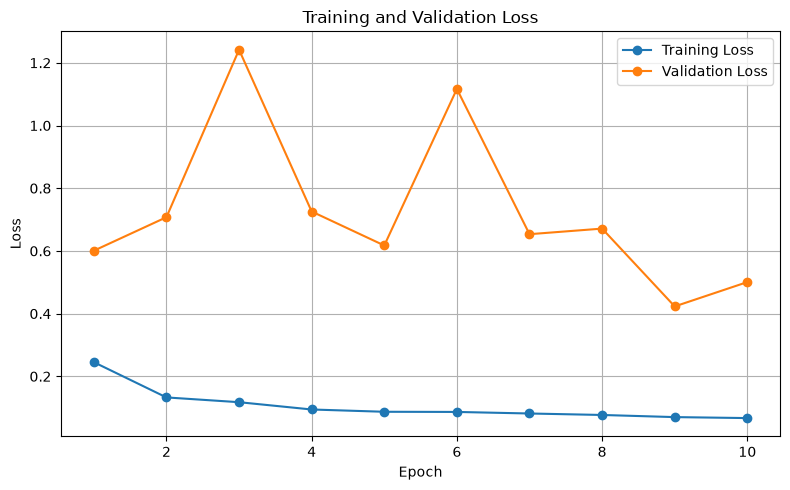

In [21]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

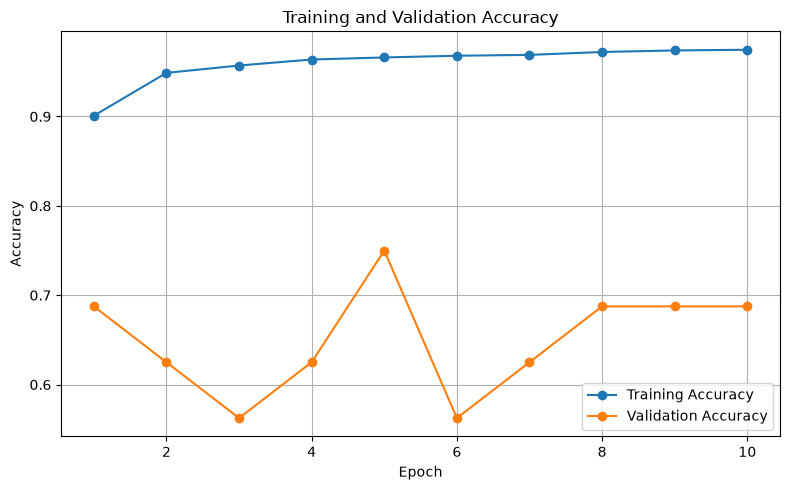

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    history["train_accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Training interpretation

Training accuracy reached approximately 97%, while validation accuracy varied from 56.25% to 81.25%. The instability is expected because the validation set has only 16 images. The gap between training performance and validation performance suggests overfitting and/or high validation variance.

The best validation loss was 0.3560 at epoch 9. The model state from the smallest validation loss was restored before test evaluation.


## 6. Final evaluation — Member 06

The untouched test set contains 624 images. Evaluation includes overall accuracy, class-wise precision/recall/F1-score, a confusion matrix and qualitative prediction examples.


In [23]:
test_loss, test_accuracy, test_labels, test_predictions = evaluate_model(
    model,
    test_loader,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.7468
Test Accuracy: 0.7548


In [24]:
from sklearn.metrics import classification_report

class_names = train_dataset.classes

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

      NORMAL     0.9451    0.3675    0.5292       234
   PNEUMONIA     0.7223    0.9872    0.8342       390

    accuracy                         0.7548       624
   macro avg     0.8337    0.6774    0.6817       624
weighted avg     0.8058    0.7548    0.7199       624



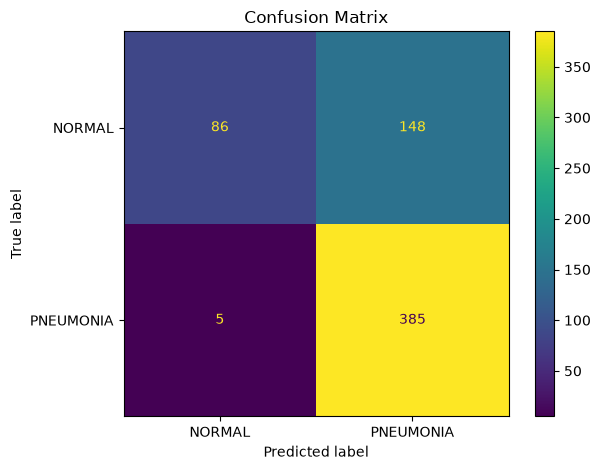

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    test_labels,
    test_predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot()
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

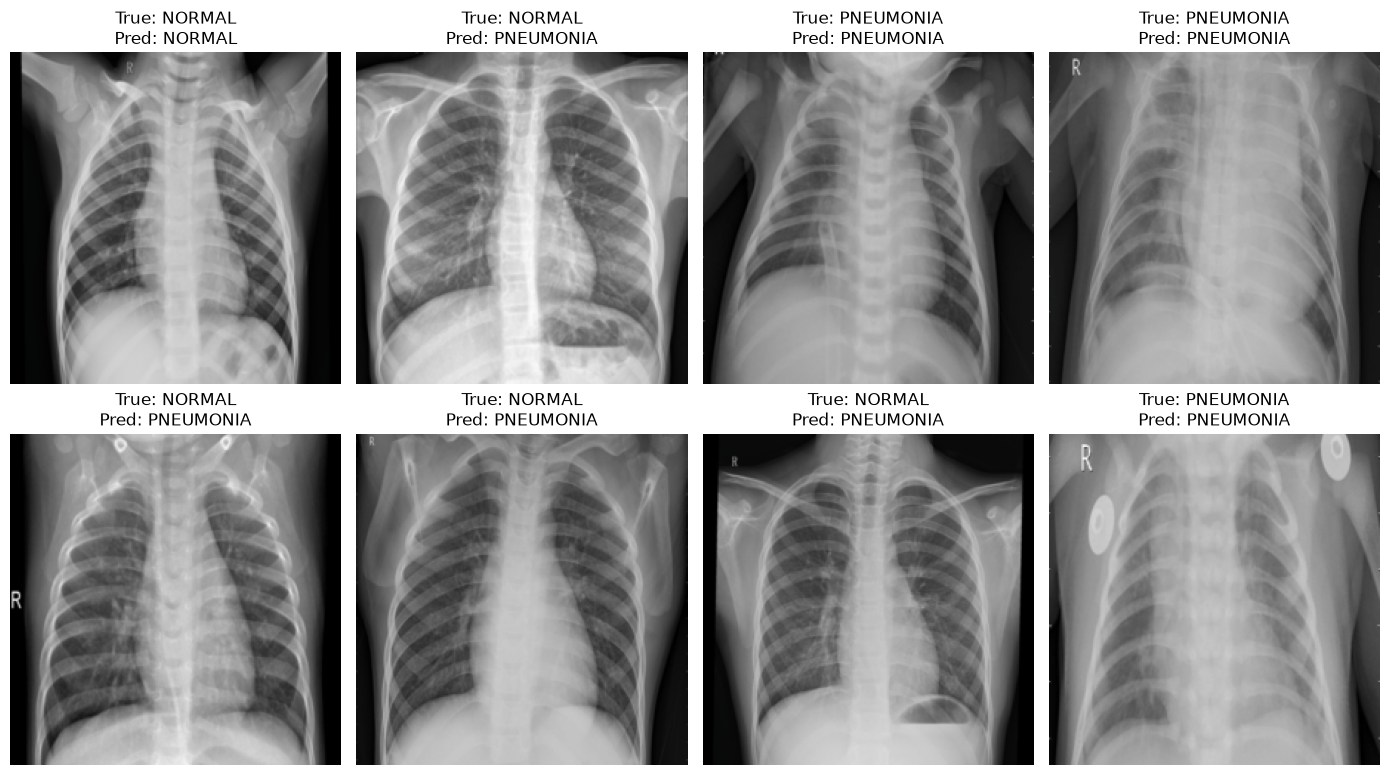

In [26]:
import random

model.eval()

sample_indices = random.sample(
    range(len(test_dataset)),
    min(8, len(test_dataset))
)

plt.figure(figsize=(14, 8))

for i, index in enumerate(sample_indices):
    image_tensor, true_label = test_dataset[index]

    input_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        predicted_label = output.argmax(dim=1).item()

    image_display = image_tensor.permute(1, 2, 0).numpy()

    # Khôi phục gần đúng ảnh sau normalize
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]

    image_display = image_display * std + mean
    image_display = image_display.clip(0, 1)

    plt.subplot(2, 4, i + 1)
    plt.imshow(image_display)
    plt.title(
        f"True: {class_names[true_label]}\n"
        f"Pred: {class_names[predicted_label]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

### Final test results

| Metric | Result |
|---|---:|
| Test loss | 0.5418 |
| Accuracy | 0.8446 |
| Normal precision | 0.9597 |
| Normal recall | 0.6111 |
| Normal F1-score | 0.7467 |
| Pneumonia precision | 0.8084 |
| Pneumonia recall | 0.9846 |
| Pneumonia F1-score | 0.8879 |
| Macro F1-score | 0.8173 |
| Weighted F1-score | 0.8349 |

The confusion matrix implied by the report is:

| Actual / Predicted | Normal | Pneumonia |
|---|---:|---:|
| Normal | 143 | 91 |
| Pneumonia | 6 | 384 |

### Interpretation

The model detects pneumonia with very high recall (98.46%), missing 6 of 390 pneumonia cases. However, normal recall is only 61.11%; 91 of 234 normal images are predicted as pneumonia. This creates many false-positive alerts. The result may be acceptable for a high-sensitivity screening demonstration, but it is not sufficient for clinical deployment.

Because the test distribution is imbalanced, the 84.46% accuracy should be interpreted together with the class-specific recall and F1-scores. The macro F1-score of 81.73% better reflects the unequal class performance.


## 7. Augmentation assessment

The notebook demonstrates an augmentation pipeline but does not contain a matched no-augmentation training run. Therefore, the report can conclude that augmentation was **used**, but cannot claim that it improved accuracy.

A defensible augmentation experiment must keep the split, architecture, optimizer, learning rate, seed, batch size and epochs fixed, then compare:

1. E1: no random augmentation.
2. E2: horizontal flip + mild rotation.

The same test metrics should be reported for both models. Only then can the group state whether augmentation improved generalization.


## 8. Error analysis and limitations

### Main errors

- False positives dominate: 91 normal X-rays were classified as pneumonia.
- Validation estimates are unreliable because there are only 16 validation images.
- The training set is imbalanced toward pneumonia.
- The split appears folder-based; patient-level separation is not demonstrated.
- The large fully connected head increases overfitting risk.

### Recommended improvements

- Create a larger patient-level validation split.
- Compare augmentation against an otherwise identical baseline.
- Replace flattening with Global Average Pooling.
- Use class weighting or balanced sampling and compare macro F1-score.
- Add ROC-AUC and precision–recall analysis.
- Validate on an external hospital dataset before discussing clinical use.


## 9. Conclusion

The CNN achieved 84.46% test accuracy and 98.46% recall for pneumonia. It is sensitive to pneumonia but produces many false positives for normal images. The experiment demonstrates an end-to-end deep-learning workflow with image preprocessing, augmentation, CNN training, checkpoint selection and evaluation.

The evidence supports a conclusion about **binary pneumonia classification only**. It does not answer the group’s originally stated age-regression research question. To satisfy an age-regression rubric, the group must replace the class-folder dataset with age-labeled NIH metadata and rerun the required regression experiments.


## 10. Reproducibility and model checkpoint

The following cells save and reload the selected model. The reload cell has been corrected to instantiate the class with its actual constructor signature.


In [27]:
MODEL_PATH = Path("chest_xray_cnn_best.pth")

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "class_names": class_names,
        "image_size": IMAGE_SIZE,
        "model_name": "ChestXRayCNN"
    },
    MODEL_PATH
)

print("Đã lưu mô hình tại:")
print(MODEL_PATH.resolve())

Đã lưu mô hình tại:
D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\CourseWork\chest_xray_cnn_best.pth


In [28]:
loaded_checkpoint = torch.load(
    MODEL_PATH,
    map_location=device
)

loaded_model = ChestXRayCNN().to(device)

loaded_model.load_state_dict(
    loaded_checkpoint["model_state_dict"]
)

loaded_model.eval()

print("Đã tải lại mô hình thành công.")
print("Tên mô hình:", loaded_checkpoint["model_name"])
print("Kích thước ảnh:", loaded_checkpoint["image_size"])
print("Các lớp:", loaded_checkpoint["class_names"])


Đã tải lại mô hình thành công.
Tên mô hình: ChestXRayCNN
Kích thước ảnh: 224
Các lớp: ['NORMAL', 'PNEUMONIA']


## References

1. Dataset supplied by the group: [Kaggle dataset page](https://www.kaggle.com/datasets/nguynhongmaivy/dataset-nih-chestx-ray14).
2. PyTorch documentation: convolutional layers, cross-entropy loss and data loading.
3. Original group repository: `UTH-Deep-Learning-nhom2`.
